# This cant satisfy C4 constraint

In [37]:
from copy import deepcopy
from scipy import stats
from scipy.spatial import cKDTree
import pandas as pd
import os
import sys
import numpy as np
from tqdm import tqdm
import networkx as nx
import random
from collections import defaultdict, Counter
from typing import Dict, List, Set, Tuple, Optional
from itertools import chain
import bisect
from collections import defaultdict
from itertools import product

seed = 0

# Set the random seed for reproducibility
random.seed(seed)
np.random.seed(seed)

base_sparsified_path = r'/raid/t2/TGN_adv/sparsified_data'
dataset_name = 'uci'

original_filename = rf'ml_{dataset_name}.csv'

print(os.path.join(base_sparsified_path, dataset_name, original_filename))

orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
orig_df.drop(['Unnamed: 0'], axis=1, inplace=True)
orig_df.head()

/raid/t2/TGN_adv/sparsified_data/uci/ml_uci.csv


,u,i,ts,label,idx
0,1,2,0,0,1
1,3,4,114878,0,2
2,5,2,373430,0,3
3,6,7,398658,0,4
4,8,7,398795,0,5


In [38]:
val_ratio = test_ratio = 0.15

val_time, test_time = list(np.quantile(orig_df.ts, [(1 - val_ratio - test_ratio), (1 - test_ratio)]))

orig_df = orig_df[orig_df['ts'] < val_time]

In [39]:
# sparsification 
sprs_type = 'ts_tpr_remove_mss'
upto = 0.7

sprs_filename = f'{dataset_name}_{sprs_type}_sparsified_{upto}.csv'
sprs_filename

full_sprs_filepath = os.path.join(base_sparsified_path, dataset_name, sprs_type, sprs_filename)

sprs_df = pd.read_csv(full_sprs_filepath)
sprs_df.sort_values('ts', inplace=True, ascending=True)
sprs_df.head()

,u,i,ts,label,idx
0,618,3,1574783,0,7419
1,621,593,1579118,0,7450
2,622,607,1583766,0,7488
3,624,452,1586078,0,7520
4,616,615,1586414,0,7526


Original:  0 3834783
Sparsified:  1574783 3833021


<Axes: >

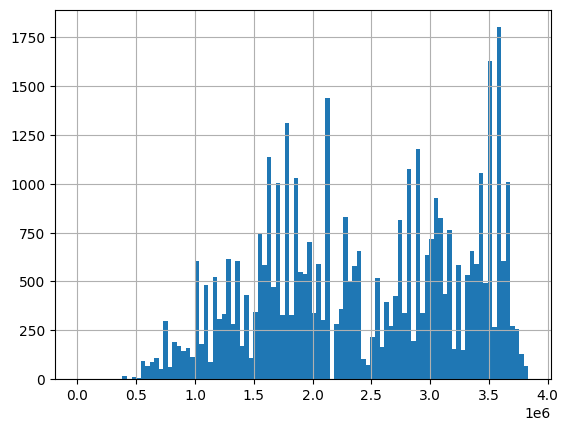

In [40]:
print('Original: ', orig_df['ts'].min(), orig_df['ts'].max())
print('Sparsified: ', sprs_df['ts'].min(), sprs_df['ts'].max())

orig_df['ts'].hist(bins=100)

In [41]:
# sprs_df['ts'].hist(bins=100)
print(orig_df['u'].nunique(), orig_df['i'].nunique())  # 1074 1459
print(sprs_df['u'].nunique(), sprs_df['i'].nunique())  # 854 1123

src, dst = orig_df['u'].unique(), orig_df['i'].unique()

set_src, set_dst = set(src), set(dst)

len(set_src.intersection(set_dst)), len(set_src.difference(set_dst))

# src_sprs, dst_sprs = sprs_df['u'].unique(), sprs_df['i'].unique()


1074 1459
854 1123


(1035, 39)

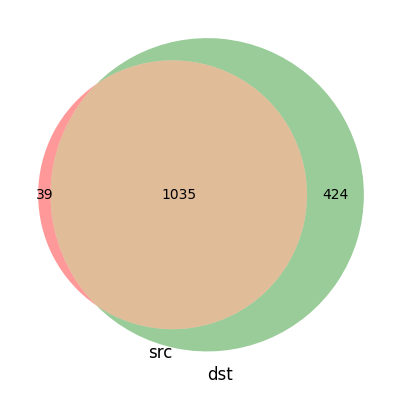

In [42]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

venn2([set_src, set_dst], ('src', 'dst'))
plt.show()

## helper

In [43]:
# # Add the project root to the Python path
# project_root = os.path.abspath(os.path.join(os.path.dirname('./'), '.'))
# sys.path.append(project_root)

# from utils.utils import NegativeEdgeSampler

def add_negative_samples(df: pd.DataFrame, start_time: float, end_time: float, 
                         negative_sample_strategy: str = 'random', 
                         num_negative_samples: int = 1, 
                         seed: int = None) -> pd.DataFrame:
    """
    Add negative samples to the input DataFrame using the NegativeEdgeSampler.
    
    :param df: Input DataFrame with columns 'source_nodes', 'target_nodes', 'interact_times'
    :param start_time: Start time for the time window
    :param end_time: End time for the time window
    :param negative_sample_strategy: Strategy for negative sampling ('random', 'historical', or 'inductive')
    :param num_negative_samples: Number of negative samples to generate for each positive sample
    :param seed: Random seed for reproducibility
    :return: DataFrame with added negative samples
    """
    # Assumption: The input DataFrame is sorted by 'interact_times'
    assert all(df['ts'].diff()[1:] >= 0), "DataFrame must be sorted by 'interact_times'"
    
    # Filter the DataFrame based on the time window
    df_filtered = df[(df['ts'] >= start_time) & (df['ts'] <= end_time)]
    
    # Initialize the NegativeEdgeSampler
    sampler = NegativeEdgeSampler(
        src_node_ids=df['u'].values,
        dst_node_ids=df['i'].values,
        interact_times=df['ts'].values,
        last_observed_time=end_time,
        negative_sample_strategy=negative_sample_strategy,
        seed=seed
    )
    
    # Generate negative samples
    negative_samples = []
    
    # Extract arrays from DataFrame for batch processing
    batch_src_node_ids = df_filtered['u'].to_numpy()
    batch_dst_node_ids = df_filtered['i'].to_numpy()
    current_batch_times = df_filtered['ts'].to_numpy()

    # Call the sampler once with the entire batch
    neg_src, neg_dst = sampler.sample(
        size=num_negative_samples * len(df_filtered),  # Multiply by the number of rows to cover all samples
        batch_src_node_ids=batch_src_node_ids,
        batch_dst_node_ids=batch_dst_node_ids,
        current_batch_start_time=start_time,  #current_batch_times.min(),  # Assuming you want to span the whole time range
        current_batch_end_time=end_time  # C3 compliant
    )
    
    # TODO: C4

    # Efficiently create negative samples
    for i in range(len(neg_src)):
        negative_samples.append({
            'u': neg_src[i],
            'i': neg_dst[i],
            # 'ts': current_batch_times[i // num_negative_samples],  # Adjust for sampling size
            # 'is_negative': 1
        })
    
    # # Create a DataFrame from negative samples
    # df_negative = pd.DataFrame(negative_samples)
    
    # # Add 'is_negative' column to the original filtered DataFrame
    # df_filtered['is_negative'] = 0
    
    # # Combine positive and negative samples
    # df_combined = pd.concat([df_filtered, df_negative], ignore_index=True)
    
    # # Sort the combined DataFrame by 'interact_times'
    # df_combined = df_combined.sort_values('ts').reset_index(drop=True)
    
    return negative_samples

ModuleNotFoundError: No module named 'utils'

In [5]:
def calculate_node_degrees(df):
    """Calculates the degree for source and destination nodes separately."""
    src_degrees = Counter(df['u'])
    dst_degrees = Counter(df['i'])
    return src_degrees, dst_degrees

def check_c3_compliance(df, negative_samples, time_window=1200*1e3):
    df_sorted = df.sort_values('ts')
    compliant = []
    for u, i, ts in negative_samples:
        window_start = max(ts - time_window, df_sorted['ts'].min())
        window_df = df_sorted[(df_sorted['ts'] >= window_start) & (df_sorted['ts'] <= ts)]
        nodes_in_window = set(window_df['u']) | set(window_df['i'])
        compliant.append((u in nodes_in_window) and (i in nodes_in_window))
    return compliant

def get_nodes_in_time_window(df: pd.DataFrame, current_time: float, window: int) -> Set[int]:
    """
    Get the set of nodes that were active within the time window before current_time.
    
    Args:
    df (pd.DataFrame): DataFrame with interactions ('u' for source, 'i' for destination, 'ts' for timestamp)
    current_time (float): Current timestamp
    window (int): Time window size
    
    Returns:
    Set[int]: Set of nodes active within the time window
    """
    window_start = max(current_time - window, df['ts'].min())
    window_df = df[(df['ts'] >= window_start) & (df['ts'] <= current_time)]
    return set(window_df['u']) | set(window_df['i'])

def create_node_mapping(original_degrees: Dict[int, int], generated_degrees: Dict[int, int]) -> Dict[int, int]:
    """
    Create a one-to-one mapping between generated and original nodes based on degree.
    
    Args:
    original_degrees (Dict[int, int]): Degree distribution of original nodes
    generated_degrees (Dict[int, int]): Degree distribution of generated nodes
    
    Returns:
    Dict[int, int]: Mapping from generated nodes to original nodes
    """
    degree_to_nodes = defaultdict(list)
    for node, degree in original_degrees.items():
        degree_to_nodes[degree].append(node)
    
    generated_degree_to_nodes = defaultdict(list)
    for node, degree in generated_degrees.items():
        generated_degree_to_nodes[degree].append(node)
    
    mapping = {}
    for degree, nodes in degree_to_nodes.items():
        generated_nodes = generated_degree_to_nodes.get(degree, [])
        for original_node, generated_node in zip(nodes, generated_nodes):
            mapping[generated_node] = original_node
    
    return mapping

In [6]:
class TemporalSampler:
    def __init__(self, original_graph, seed=None, time_window=1200, 
                 num_bins=100, min_activity_threshold=2):
        """
        Enhanced Temporal Sampler with activity awareness and adaptive sampling
        
        Args:
            original_graph: DataFrame with 'ts', 'u', 'i' columns
            seed: Random seed
            time_window: Time window size for node availability
            num_bins: Number of temporal bins for activity analysis
            min_activity_threshold: Minimum number of nodes required in a time period
        """
        self.original_graph = original_graph
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.time_window = time_window
        self.num_bins = num_bins
        self.min_activity_threshold = min_activity_threshold
        
        # Time bounds
        self.min_time = max(0, original_graph['ts'].min()) # min(0, original_graph['ts'].min())
        self.max_time = original_graph['ts'].max()
        self.time_range = self.max_time - self.min_time
        
        # Initialize components
        self._compute_activity_density()
        self._initialize_kde()
        self._initialize_node_windows()
        
    def _compute_activity_density(self):
        """Compute temporal activity density and identify active periods"""
        # Create temporal bins
        self.bin_edges = np.linspace(self.min_time, self.max_time, self.num_bins + 1)
        self.bin_width = (self.max_time - self.min_time) / self.num_bins
        
        # Compute activity density
        df_sorted = self.original_graph.sort_values('ts')
        hist, _ = np.histogram(df_sorted['ts'], bins=self.bin_edges)
        self.activity_density = hist / hist.sum()
        
        # Track node activities
        self.src_activity = defaultdict(list)
        self.dst_activity = defaultdict(list)
        
        for _, row in df_sorted.iterrows():
            bin_idx = np.searchsorted(self.bin_edges, row['ts']) - 1
            if bin_idx < self.num_bins:
                self.src_activity[row['u']].append(bin_idx)
                self.dst_activity[row['i']].append(bin_idx)
        
        # Identify active periods
        self.active_bins = np.where(hist >= self.min_activity_threshold)[0]
        self.active_periods = self._merge_active_periods()
        
    def _merge_active_periods(self):
        """Merge consecutive active periods"""
        if len(self.active_bins) == 0:
            return []
            
        periods = []
        start = self.active_bins[0]
        prev = start
        
        for bin_idx in self.active_bins[1:]:
            if bin_idx - prev > 1:
                periods.append((
                    self.bin_edges[start],
                    self.bin_edges[prev + 1]
                ))
                start = bin_idx
            prev = bin_idx
            
        periods.append((
            self.bin_edges[start],
            self.bin_edges[prev + 1]
        ))
        
        return periods
        
    def _initialize_kde(self):
        """Initialize adaptive KDE with local bandwidth"""
        df_sorted = self.original_graph.sort_values('ts')
        inter_event_times = np.diff(df_sorted['ts'])
        
        # Compute local density for adaptive bandwidth
        local_density = []
        window_size = len(inter_event_times) // 20  # 5% of data
        
        for i in range(len(inter_event_times)):
            start_idx = max(0, i - window_size//2)
            end_idx = min(len(inter_event_times), i + window_size//2)
            local_density.append(len(inter_event_times[start_idx:end_idx]))
            
        local_density = np.array(local_density)
        self.bandwidths = 1 / np.sqrt(local_density + 1)  # Adaptive bandwidth
        
        # Initialize KDE with adaptive bandwidth
        # self.kde = stats.gaussian_kde(
        #     inter_event_times,
        #     bw_method=np.mean(self.bandwidths)
        # )
        
        # Fit KDE on the raw timestamps to capture the distribution directly
        self.kde = stats.gaussian_kde(df_sorted['ts'], bw_method='silverman')
        
    def _initialize_node_windows(self):
        """Track node availability windows"""
        df_sorted = self.original_graph.sort_values('ts')
        self.node_windows = defaultdict(list)
        
        window_starts = df_sorted['ts'].values
        window_ends = window_starts + self.time_window
        
        for ts, u, i in df_sorted[['ts', 'u', 'i']].values:
            self.node_windows[u].append((ts, ts + self.time_window))
            self.node_windows[i].append((ts, ts + self.time_window))
            
        # Merge overlapping windows
        for node in self.node_windows:
            merged = []
            current = None
            
            for window in sorted(self.node_windows[node]):
                if current is None:
                    current = list(window)
                elif window[0] <= current[1]:
                    current[1] = max(current[1], window[1])
                else:
                    merged.append(tuple(current))
                    current = list(window)
                    
            if current is not None:
                merged.append(tuple(current))
                
            self.node_windows[node] = merged

    def assign_timestamps(self, num_samples):
        """
        Assign timestamps using activity-aware sampling
        """
        sampled_timestamps = []
        required_samples = num_samples
        
        # Sample from active periods with higher probability
        while len(sampled_timestamps) < required_samples:
            # Choose active period weighted by activity density
            period_weights = [
                np.sum(self.activity_density[
                    np.searchsorted(self.bin_edges, start):
                    np.searchsorted(self.bin_edges, end)
                ])
                for start, end in self.active_periods
            ]
            period_weights = np.array(period_weights) / np.sum(period_weights)
            
            chosen_period = self.active_periods[
                self.rng.choice(len(self.active_periods), p=period_weights)
            ]
            
            # Sample timestamps within chosen period
            local_samples = min(
                required_samples - len(sampled_timestamps),
                max(1, int(required_samples * period_weights[0]))
            )
            
            # Generate samples using KDE
            kde_samples = self.kde.resample(local_samples, self.rng)[0]
            timestamps = np.cumsum(kde_samples) + chosen_period[0]
            timestamps = timestamps[timestamps <= chosen_period[1]]
            
            # Add jitter while maintaining window constraints
            jitter = self.rng.uniform(
                -self.time_window * 0.05,
                self.time_window * 0.05,
                len(timestamps)
            )
            timestamps += jitter
            
            # Ensure timestamps are within bounds
            timestamps = np.clip(timestamps, self.min_time, self.max_time)
            sampled_timestamps.extend(timestamps)
            
        sampled_timestamps = np.array(sorted(sampled_timestamps[:num_samples]))
        return sampled_timestamps
        
    def get_activity_metrics(self):
        """Return activity metrics for analysis"""
        return {
            'activity_density': self.activity_density,
            'active_periods': self.active_periods,
            'bin_edges': self.bin_edges,
            'total_active_bins': len(self.active_bins)
        }

In [7]:
class LoserTemporalSampler:
    def __init__(self, original_graph, seed=None, time_window=1200, 
                 num_bins=100, min_activity_threshold=2):
        """
        Enhanced Temporal Sampler with activity awareness and adaptive sampling
        
        Args:
            original_graph: DataFrame with 'ts', 'u', 'i' columns
            seed: Random seed
            time_window: Time window size for node availability
            num_bins: Number of temporal bins for activity analysis
            min_activity_threshold: Minimum number of nodes required in a time period
        """
        self.original_graph = original_graph
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.time_window = time_window
        self.num_bins = num_bins
        self.min_activity_threshold = min_activity_threshold
        
        # Time bounds
        self.min_time = max(0, original_graph['ts'].min()) # min(0, original_graph['ts'].min())
        self.max_time = original_graph['ts'].max()
        self.time_range = self.max_time - self.min_time
        
        # Initialize components
        self._compute_activity_density()
        self._initialize_kde()
        self._initialize_node_windows()
        
    def _compute_activity_density(self):
        """Compute temporal activity density and identify active periods"""
        # Create temporal bins
        self.bin_edges = np.linspace(self.min_time, self.max_time, self.num_bins + 1)
        self.bin_width = (self.max_time - self.min_time) / self.num_bins
        
        # Compute activity density
        df_sorted = self.original_graph.sort_values('ts')
        hist, _ = np.histogram(df_sorted['ts'], bins=self.bin_edges)
        self.activity_density = hist / hist.sum()
        
        # Track node activities
        self.src_activity = defaultdict(list)
        self.dst_activity = defaultdict(list)
        
        for _, row in df_sorted.iterrows():
            bin_idx = np.searchsorted(self.bin_edges, row['ts']) - 1
            if bin_idx < self.num_bins:
                self.src_activity[row['u']].append(bin_idx)
                self.dst_activity[row['i']].append(bin_idx)
        
        # Identify active periods
        self.active_bins = np.where(hist >= self.min_activity_threshold)[0]
        self.active_periods = self._merge_active_periods()
        
    def _merge_active_periods(self):
        """Merge consecutive active periods"""
        if len(self.active_bins) == 0:
            return []
            
        periods = []
        start = self.active_bins[0]
        prev = start
        
        for bin_idx in self.active_bins[1:]:
            if bin_idx - prev > 1:
                periods.append((
                    self.bin_edges[start],
                    self.bin_edges[prev + 1]
                ))
                start = bin_idx
            prev = bin_idx
            
        periods.append((
            self.bin_edges[start],
            self.bin_edges[prev + 1]
        ))
        
        return periods
        
    def _initialize_kde(self):
        """Initialize adaptive KDE with local bandwidth"""
        df_sorted = self.original_graph.sort_values('ts')
        inter_event_times = np.diff(df_sorted['ts'])
        
        # Compute local density for adaptive bandwidth
        local_density = []
        window_size = len(inter_event_times) // 20  # 5% of data
        
        for i in range(len(inter_event_times)):
            start_idx = max(0, i - window_size//2)
            end_idx = min(len(inter_event_times), i + window_size//2)
            local_density.append(len(inter_event_times[start_idx:end_idx]))
            
        local_density = np.array(local_density)
        self.bandwidths = 1 / np.sqrt(local_density + 1)  # Adaptive bandwidth
        
        # Initialize KDE with adaptive bandwidth
        self.kde = stats.gaussian_kde(
            inter_event_times,
            bw_method=np.mean(self.bandwidths)
        )
        
    def _initialize_node_windows(self):
        """Track node availability windows"""
        df_sorted = self.original_graph.sort_values('ts')
        self.node_windows = defaultdict(list)
        
        window_starts = df_sorted['ts'].values
        window_ends = window_starts + self.time_window
        
        for ts, u, i in df_sorted[['ts', 'u', 'i']].values:
            self.node_windows[u].append((ts, ts + self.time_window))
            self.node_windows[i].append((ts, ts + self.time_window))
            
        # Merge overlapping windows
        for node in self.node_windows:
            merged = []
            current = None
            
            for window in sorted(self.node_windows[node]):
                if current is None:
                    current = list(window)
                elif window[0] <= current[1]:
                    current[1] = max(current[1], window[1])
                else:
                    merged.append(tuple(current))
                    current = list(window)
                    
            if current is not None:
                merged.append(tuple(current))
                
            self.node_windows[node] = merged

    def __assign_timestamps(self, num_samples):
        """
        Assign timestamps using activity-aware sampling
        """
        sampled_timestamps = []
        required_samples = num_samples
        
        # Sample from active periods with higher probability
        while len(sampled_timestamps) < required_samples:
            # Choose active period weighted by activity density
            period_weights = [
                np.sum(self.activity_density[
                    np.searchsorted(self.bin_edges, start):
                    np.searchsorted(self.bin_edges, end)
                ])
                for start, end in self.active_periods
            ]
            period_weights = np.array(period_weights) / np.sum(period_weights)
            
            chosen_period = self.active_periods[
                self.rng.choice(len(self.active_periods), p=period_weights)
            ]
            
            # Sample timestamps within chosen period
            local_samples = min(
                required_samples - len(sampled_timestamps),
                max(1, int(required_samples * period_weights[0]))
            )
            
            # Generate samples using KDE
            kde_samples = self.kde.resample(local_samples, self.rng)[0]
            timestamps = np.cumsum(kde_samples) + chosen_period[0]
            timestamps = timestamps[timestamps <= chosen_period[1]]
            
            # Add jitter while maintaining window constraints
            jitter = self.rng.uniform(
                -self.time_window * 0.05,
                self.time_window * 0.05,
                len(timestamps)
            )
            timestamps += jitter
            
            # Ensure timestamps are within bounds
            timestamps = np.clip(timestamps, self.min_time, self.max_time)
            sampled_timestamps.extend(timestamps)
            
        sampled_timestamps = np.array(sorted(sampled_timestamps[:num_samples]))
        return sampled_timestamps
        
    def assign_timestamps(self, num_samples):
        """
        Assign timestamps using activity-aware KDE sampling.
        """
        sampled_timestamps = []
        
        # Generate samples from the KDE directly, avoiding binning
        kde_samples = self.kde.resample(num_samples)[0]
        
        # Clip samples to ensure they fall within min_time and max_time bounds
        sampled_timestamps = np.clip(kde_samples, self.min_time, self.max_time)
        
        # Sort timestamps for any downstream processing that assumes order
        return np.array(sorted(sampled_timestamps))
    
    def get_activity_metrics(self):
        """Return activity metrics for analysis"""
        return {
            'activity_density': self.activity_density,
            'active_periods': self.active_periods,
            'bin_edges': self.bin_edges,
            'total_active_bins': len(self.active_bins)
        }

In [8]:
# VFinal

class EdgeTimestampSelector:
   def __init__(self,
                feasible_edges_dict: Dict,
                original_df: pd.DataFrame, 
                degree_dict: Dict[int, int],
                removed_edges: Set[Tuple[int, int]],
                src_nodes: Optional[Set[int]] = None,
                dst_nodes: Optional[Set[int]] = None,
                time_window:int=1200):
       """Initialize Edge-Timestamp Selector"""
       self.feasible_edges_dict = feasible_edges_dict
       self.original_df = original_df
       self.degree_dict = degree_dict
       self.removed_edges = removed_edges
       self.is_bipartite = src_nodes is not None and dst_nodes is not None
       self.src_nodes = src_nodes
       self.dst_nodes = dst_nodes
       self.time_window = time_window
       
       # Initialize tracking structures
       self.node_usage = defaultdict(int)
       self.selected_pairs = []
       self.remaining_capacity = deepcopy(degree_dict)
       
       # Calculate edge budget and create lookup structures
       self.max_edges = self._calculate_edge_budget()
       self.node_to_edges = self._create_node_edge_mapping()
       self.feasible_adj_lists = self._create_adj_lists()
           
   def _calculate_edge_budget(self) -> int:
       """Calculate maximum possible edges"""
       if self.is_bipartite:
           src_sum = sum(self.degree_dict[n] for n in self.src_nodes)
           dst_sum = sum(self.degree_dict[n] for n in self.dst_nodes)
           return src_sum
       return sum(self.degree_dict.values()) // 2
       
   def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
       """Create mapping from nodes to their edges"""
       node_to_edges = defaultdict(list)
       for edge in self.feasible_edges_dict:
           u, v = edge
           node_to_edges[u].append(edge)
           node_to_edges[v].append(edge)
       return node_to_edges

   def _create_adj_lists(self) -> Dict[int, Set[int]]:
       """Create adjacency lists for faster lookup"""
       adj_lists = defaultdict(set)
       for (u, v) in self.feasible_edges_dict:
           adj_lists[u].add(v)
           if not self.is_bipartite:
               adj_lists[v].add(u)
       return adj_lists
       
   def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
       """Main edge selection algorithm"""
       # Sort nodes by degree for priority
       priority_nodes = sorted(
           self.degree_dict.keys(),
           key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
           reverse=True
       )
       
       selected_count = 0
       pbar = tqdm(total=self.max_edges, desc="Selecting edges")
       
       # Initial edge selection phase
       for node in priority_nodes:
           if selected_count >= self.max_edges:
               break
               
           if self.remaining_capacity[node] <= 0:
               continue
               
           while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
               candidates = self._get_candidates(node)
               if not candidates:
                   break
                   
               scored_candidates = [
                   (self._calculate_score(edge, timestamps), edge, timestamps) 
                   for edge, timestamps in candidates
               ]
               scored_candidates.sort(reverse=True)
               
               selected = False
               for _, edge, timestamps in scored_candidates:
                   if self._can_select(edge, timestamps):
                       best_timestamp = self._pick_best_timestamp(timestamps, edge)
                       self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                       self._update_tracking(edge)
                       selected_count += 1
                       pbar.update(1)
                       selected = True
                       break
                       
               if not selected:
                   break
       
       # Recovery phase if needed
       if selected_count < self.max_edges:
           remaining = self.max_edges - selected_count
           additional_edges = self._fast_recovery_phase(remaining, self.original_df)
           selected_count += len(additional_edges)
           pbar.update(len(additional_edges))
       
       pbar.close()
       self._validate_selections()
       return self.selected_pairs

   def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame) -> List[Tuple[int, int, int]]:
       """Recovery phase with C3 compliance and optimized window queries"""
       additional_edges = []
       
       # Pre-process data
       df_sorted = original_df.sort_values('ts').set_index('ts')
       node_appearances = defaultdict(list)
       for idx, row in df_sorted.iterrows():
           node_appearances[row['u']].append(idx)
           node_appearances[row['i']].append(idx)
       
       available_src_nodes = [n for n in self.src_nodes if self.remaining_capacity[n] > 0]
       available_dst_nodes = [n for n in self.dst_nodes if self.remaining_capacity[n] > 0]
       used_pairs = {(e[0], e[1]) for e in self.selected_pairs}
       
       all_timestamps = sorted(list(set(
           ts for timestamps in self.feasible_edges_dict.values() 
           for ts in timestamps
       )))
       
       window_cache = {}
       window_size = self.time_window*1e3
    #    window_size = 1200*1e3  # original
       
       def get_nodes_in_window(timestamp: float) -> Set[int]:
           if timestamp in window_cache:
               return window_cache[timestamp]
               
           window_start = max(timestamp - window_size, df_sorted.index.min())
           nodes_in_window = set()
           
           for node in chain(available_src_nodes, available_dst_nodes):
               appearances = node_appearances[node]
               idx = bisect.bisect_left(appearances, window_start)
               if idx < len(appearances) and appearances[idx] <= timestamp:
                   nodes_in_window.add(node)
           
           window_cache[timestamp] = nodes_in_window
           return nodes_in_window
       
       # Process timestamps in batches
       batch_size = 1000
       for i in range(0, len(all_timestamps), batch_size):
           batch_timestamps = all_timestamps[i:i + batch_size]
           
           for ts in batch_timestamps:
               get_nodes_in_window(ts)
           
           for timestamp in batch_timestamps:
               if len(additional_edges) >= needed_edges:
                   break
                   
               nodes_in_window = window_cache[timestamp]
               valid_src = [n for n in available_src_nodes 
                          if n in nodes_in_window and self.remaining_capacity[n] > 0]
               valid_dst = [n for n in available_dst_nodes 
                          if n in nodes_in_window and self.remaining_capacity[n] > 0]
               
               for src_node in valid_src:
                   if len(additional_edges) >= needed_edges:
                       break
                       
                   for dst_node in valid_dst:
                       edge = (src_node, dst_node)
                       if edge not in used_pairs and self._can_select(edge, [timestamp]):
                           additional_edges.append((src_node, dst_node, timestamp))
                           used_pairs.add(edge)
                           self._update_tracking(edge)
                           
                           if len(additional_edges) >= needed_edges:
                               break
                               
           window_cache.clear()
       
       self.selected_pairs.extend(additional_edges)
       return additional_edges

   def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
       """Get valid candidate edges for a node"""
       return [(edge, self.feasible_edges_dict[edge]) 
               for edge in self.node_to_edges[node]
               if self.remaining_capacity[self._get_other_node(edge, node)] > 0 
               and edge in self.feasible_edges_dict]

   def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
       """Get the other node in an edge"""
       u, v = edge
       return v if node == u else u
       
   def _calculate_score(self, edge: Tuple[int, int], timestamps: List[int]) -> float:
       """Calculate score for candidate edge"""
       u, v = edge
       score = (self.remaining_capacity[u] + self.remaining_capacity[v] + 
               len(timestamps) - (self.node_usage[u] + self.node_usage[v]) * 10)
       if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
           score += 50
       return score
       
   def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
       """Check if edge can be selected"""
       u, v = edge
       if not timestamps or self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
           return False
       if self.is_bipartite and ((u in self.src_nodes and v in self.src_nodes) or 
                                (u in self.dst_nodes and v in self.dst_nodes)):
           return False
       return True

   def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
       """Select best timestamp from available options"""
       return min(timestamps)

   def _update_tracking(self, edge: Tuple[int, int]):
       """Update tracking after edge selection"""
       u, v = edge
       self.remaining_capacity[u] -= 1
       self.remaining_capacity[v] -= 1
       self.node_usage[u] += 1
       self.node_usage[v] += 1

   def _validate_selections(self):
       """Validate final selections"""
       node_counts = defaultdict(int)
       for u, v, _ in self.selected_pairs:
           node_counts[u] += 1
           node_counts[v] += 1
           
       src_used = len([n for n in node_counts if n in self.src_nodes])
       dst_used = len([n for n in node_counts if n in self.dst_nodes])
       
       if self.is_bipartite:
           print(f"Source nodes used: {src_used}")
           print(f"Destination nodes used: {dst_used}")

## Code

In [44]:
start_time, end_time = min(0, orig_df['ts'].min()), orig_df['ts'].max()

neg_samples = add_negative_samples(sprs_df, start_time, end_time, 
                                      negative_sample_strategy='random', 
                                      num_negative_samples=5,  # how to choose this ??
                                      seed=0)

print(len(neg_samples))

neg_samples = pd.DataFrame(neg_samples)[['u', 'i']].apply(tuple, axis=1).tolist()
# neg_samples = neg_samples[:10000]
len(neg_samples)

NameError: name 'add_negative_samples' is not defined

In [10]:
time_window = 1200
seed = 0

# Convert the edges to a comparable format while keeping the index
last_edges = set(orig_df[['u', 'i', 'ts']].apply(tuple, axis=1))
sprs_edges = set(sprs_df[['u', 'i', 'ts']].apply(tuple, axis=1))

# Find missing edges including timestamps
missing_edges = last_edges - sprs_edges

batch_cut = len(missing_edges) // 6
print('batch_cut: ', batch_cut)

# Convert back to dataframe preserving all columns
missing_edges_df = pd.DataFrame(list(missing_edges), columns=['u', 'i', 'ts'])

missing_edges_df = missing_edges_df.iloc[:batch_cut, :]
len(missing_edges_df)

num_samples_needed = len(missing_edges_df) # len(orig_df) - len(sprs_df)

print(num_samples_needed)

# Initialize TemporalSampler
sampler = TemporalSampler(missing_edges_df, time_window=time_window, seed=seed)

# Generate timestamps for all potential negative samples
sampled_timestamps = sampler.assign_timestamps(num_samples_needed)
len(sampled_timestamps)

batch_cut:  9109
9109


9109

In [11]:
removed_edges = missing_edges_df[['u', 'i']].values.tolist()
print(len(missing_edges_df))

deficit_src_degree, deficit_dst_degree = calculate_node_degrees(missing_edges_df)
sum(deficit_src_degree.values()), sum(deficit_src_degree.values())

9109


(9109, 9109)

In [12]:
# neg_samples = neg_samples[:len(missing_edges_df)]
# len(neg_samples)

In [13]:
df_sorted =missing_edges_df.sort_values('ts')  # missing_edges_df
original_edges = set(tuple(x) for x in df_sorted[['u', 'i']].values)

min_src, max_src = orig_df['u'].min(), orig_df['u'].max()
min_dst, max_dst = orig_df['i'].min(), orig_df['i'].max()

In [14]:
from collections import defaultdict

# Precompute a mapping from nodes to edges to speed up validation
node_to_edges = defaultdict(list)

for edge in neg_samples:
    node_to_edges[edge[0]].append(edge)
    node_to_edges[edge[1]].append(edge)

# Initialize the mapping dictionaries
map_ts_to_edges = {}
map_edges_to_ts = defaultdict(list)

for timestamp in tqdm(sampled_timestamps, desc='Processing'):
    # Get active nodes in the time window
    nodes_in_window = set(get_nodes_in_time_window(df_sorted, timestamp, time_window))
    
    # Use set intersections for efficient filtering
    valid_edges = []
    for node in nodes_in_window:
        for edge in node_to_edges[node]:
            if edge[0] in nodes_in_window and edge[1] in nodes_in_window:
                valid_edges.append(edge)

    # Remove duplicates from valid_edges (in case nodes appear multiple times)
    valid_edges = list(set(valid_edges))
    
    # Update the mappings
    map_ts_to_edges[timestamp] = valid_edges
    for edge in valid_edges:
        map_edges_to_ts[edge].append(timestamp)

Processing: 100%|██████████| 9109/9109 [00:04<00:00, 2066.01it/s]


In [15]:
feasible_edges_dict = deepcopy(map_edges_to_ts)
# orig_src_degrees, orig_dst_degrees
degree_dict = deepcopy(deficit_src_degree)
degree_dict.update(deficit_dst_degree)

selector = EdgeTimestampSelector(
    feasible_edges_dict=feasible_edges_dict,
    original_df=missing_edges_df,
    degree_dict=degree_dict,
    removed_edges=removed_edges,
    src_nodes=set(deficit_src_degree.keys()),
    dst_nodes=set(deficit_dst_degree.keys()),
    time_window=time_window
)

new_edges = selector.select_edges_timestamps()

print('newly generated edges are ', len(new_edges))

Selecting edges:  99%|█████████▉| 9051/9109 [00:02<00:00, 3508.00it/s]

Source nodes used: 1689
Destination nodes used: 772
newly generated edges are  9051


In [16]:
len(map_edges_to_ts)

2033

## Check

In [17]:
ns_df = pd.DataFrame(new_edges, columns=['u', 'i', 'ts'])
ns_df.sort_values('ts', inplace=True)
ns_df.head()

,u,i,ts
1216,5.0,8249.0,1870.065745
1225,5.0,8249.0,1870.065745
1230,5.0,8249.0,1870.065745
1235,5.0,8249.0,1870.065745
1220,5.0,8249.0,1870.065745


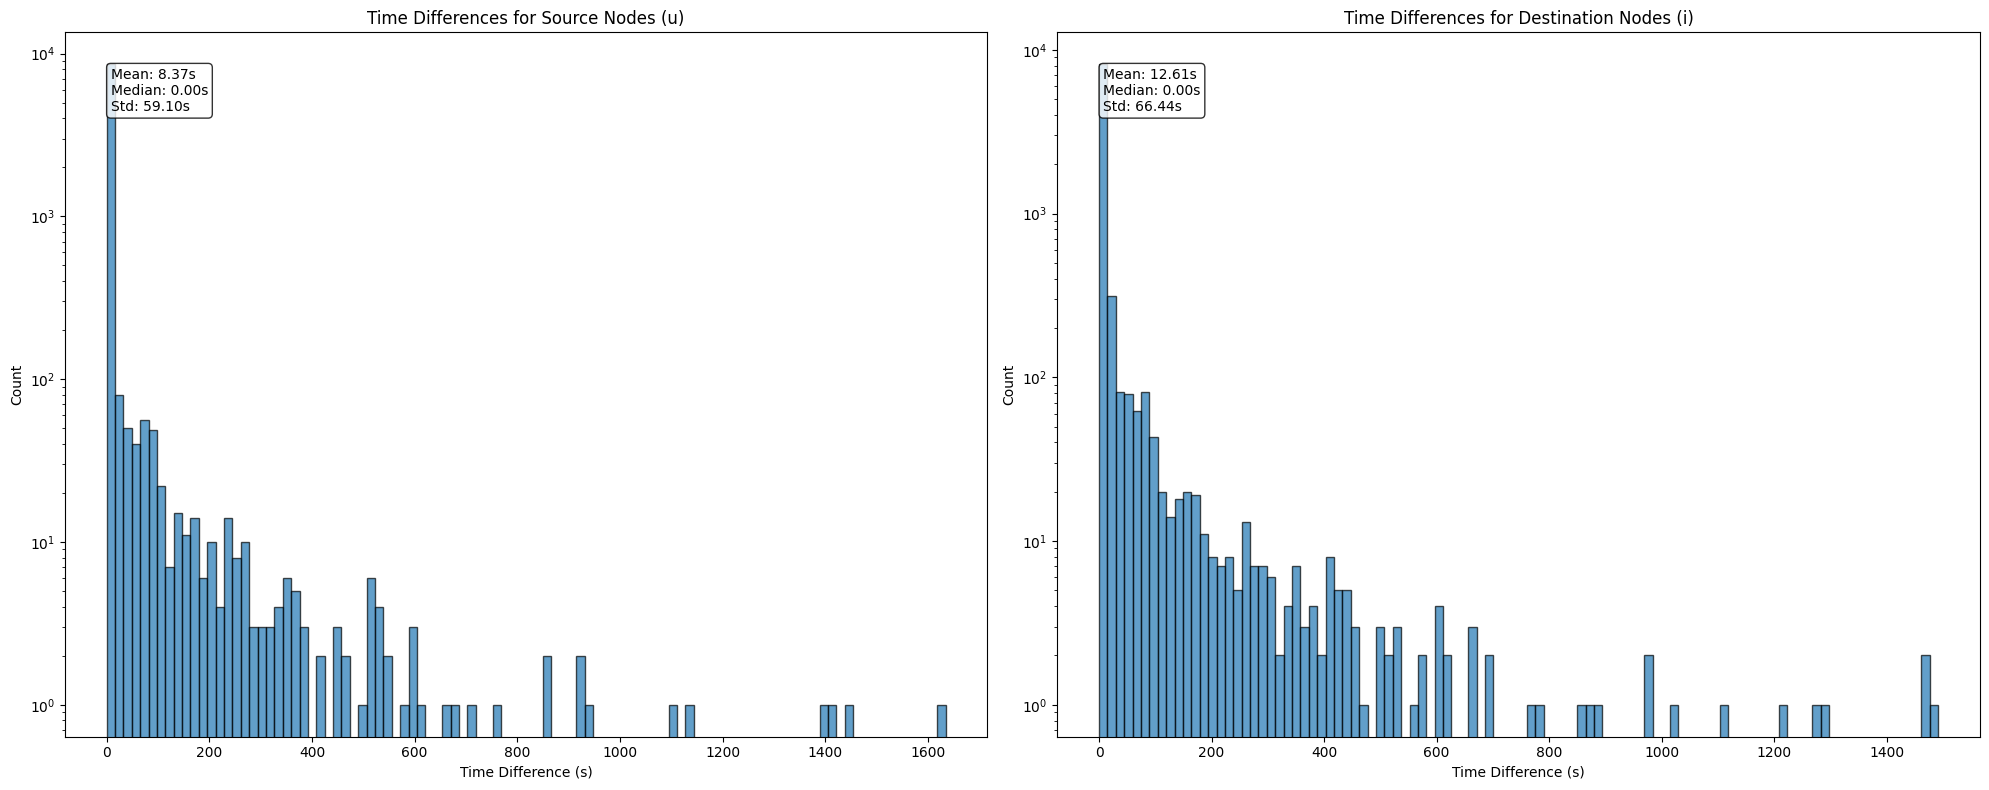

In [18]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot for source nodes (u)
ns_df_u = ns_df.sort_values(['u', 'ts'])
ns_df_u['diff'] = ns_df_u.groupby(['u'])['ts'].diff().fillna(0)
ts_diffs_u = ns_df_u['diff'].dropna()

ax1.hist(ts_diffs_u/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax1.set_ylabel('Count')
ax1.set_xlabel('Time Difference (s)')
ax1.set_title('Time Differences for Source Nodes (u)')

# Calculate and display statistics for u
mean_diff_u = ts_diffs_u.mean()
median_diff_u = ts_diffs_u.median()
std_diff_u = ts_diffs_u.std()

ax1.text(0.05, 0.95, f'Mean: {mean_diff_u/1e3:.2f}s\nMedian: {median_diff_u/1e3:.2f}s\nStd: {std_diff_u/1e3:.2f}s', 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot for destination nodes (i)
ns_df_i = ns_df.sort_values(['i', 'ts'])
ns_df_i['diff'] = ns_df_i.groupby(['i'])['ts'].diff().fillna(0)
ts_diffs_i = ns_df_i['diff'].dropna()

ax2.hist(ts_diffs_i/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax2.set_ylabel('Count')
ax2.set_xlabel('Time Difference (s)')
ax2.set_title('Time Differences for Destination Nodes (i)')

# Calculate and display statistics for i
mean_diff_i = ts_diffs_i.mean()
median_diff_i = ts_diffs_i.median()
std_diff_i = ts_diffs_i.std()

ax2.text(0.05, 0.95, f'Mean: {mean_diff_i/1e3:.2f}s\nMedian: {median_diff_i/1e3:.2f}s\nStd: {std_diff_i/1e3:.2f}s', 
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

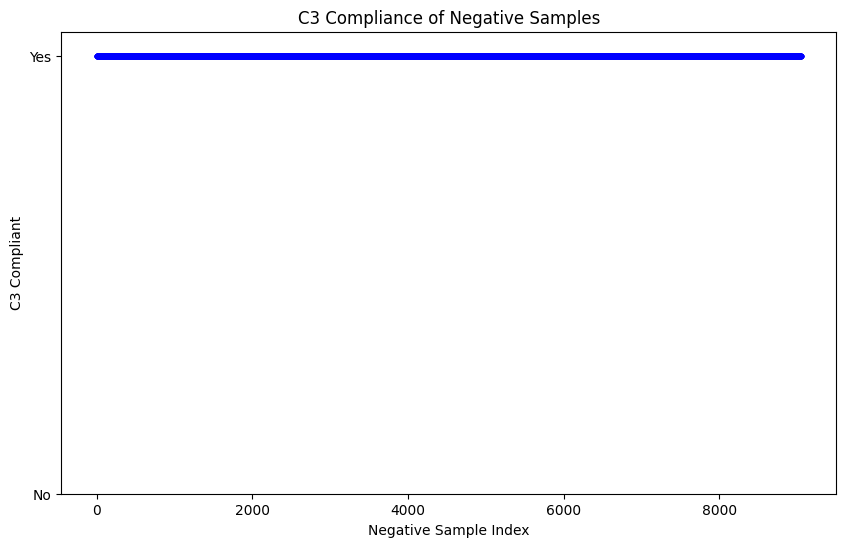

Percentage of C3 compliant samples: 100.00%


In [19]:
compliant = check_c3_compliance(missing_edges_df, new_edges)

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title('C3 Compliance of Negative Samples')
plt.yticks([0, 1], ['No', 'Yes'])
plt.show()

print(f"Percentage of C3 compliant samples: {sum(compliant)/len(compliant)*100:.2f}%")

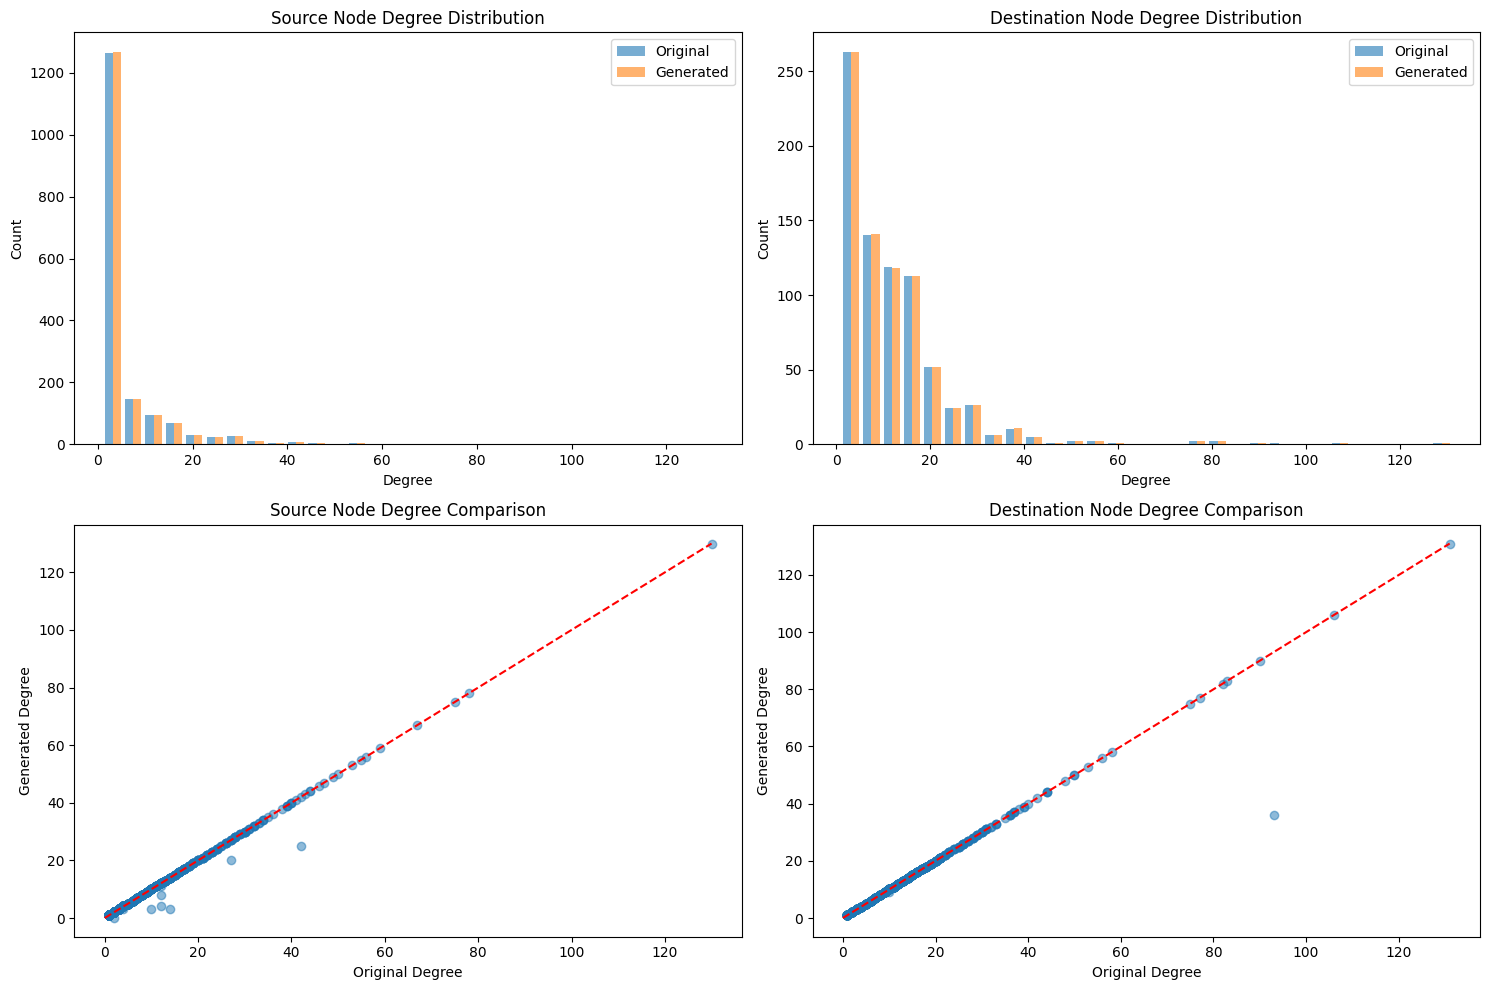

Source degree correlation: nan
Destination degree correlation: 0.987


In [20]:
def plot_degree_comparison(df1, df2, src_col='u', dst_col='i'):
    """
    Visualize degree distribution comparison between two DataFrames
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Calculate degree distributions
    src_degrees1 = Counter(df1[src_col])
    dst_degrees1 = Counter(df1[dst_col])
    src_degrees2 = Counter(df2[src_col])
    dst_degrees2 = Counter(df2[dst_col])
    
    # Plot 1: Source Node Degree Distribution
    degrees1 = list(src_degrees1.values())
    degrees2 = list(src_degrees2.values())
    ax1.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax1.set_title('Source Node Degree Distribution')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.legend()
    
    # Plot 2: Destination Node Degree Distribution
    degrees1 = list(dst_degrees1.values())
    degrees2 = list(dst_degrees2.values())
    ax2.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax2.set_title('Destination Node Degree Distribution')
    ax2.set_xlabel('Degree')
    ax2.set_ylabel('Count')
    ax2.legend()
    
    # Plot 3: Source Node Degree Scatter
    x = sorted(set(src_degrees1.keys()) | set(src_degrees2.keys()))
    y1 = [src_degrees1.get(k, 0) for k in x]
    y2 = [src_degrees2.get(k, 0) for k in x]
    ax3.scatter(y1, y2, alpha=0.5)
    ax3.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax3.set_title('Source Node Degree Comparison')
    ax3.set_xlabel('Original Degree')
    ax3.set_ylabel('Generated Degree')
    
    # Plot 4: Destination Node Degree Scatter
    x = sorted(set(dst_degrees1.keys()) | set(dst_degrees2.keys()))
    y1 = [dst_degrees1.get(k, 0) for k in x]
    y2 = [dst_degrees2.get(k, 0) for k in x]
    ax4.scatter(y1, y2, alpha=0.5)
    ax4.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax4.set_title('Destination Node Degree Comparison')
    ax4.set_xlabel('Original Degree')
    ax4.set_ylabel('Generated Degree')
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistics
    src_corr = np.corrcoef(
        [src_degrees1.get(k, 0) for k in x],
        [src_degrees2.get(k, 0) for k in x]
    )[0,1]
    dst_corr = np.corrcoef(
        [dst_degrees1.get(k, 0) for k in x],
        [dst_degrees2.get(k, 0) for k in x]
    )[0,1]
    
    print(f"Source degree correlation: {src_corr:.3f}")
    print(f"Destination degree correlation: {dst_corr:.3f}")
    

plot_degree_comparison(missing_edges_df, ns_df)